In [250]:
# !pip install numpy 
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install seaborn
# !pip install plotly-express
# !pip install lightgbm

In [251]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from statsmodels.graphics.gofplots import qqplot
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import sklearn.gaussian_process as gp
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import matplotlib.dates as mdates
import lightgbm as lgb

In [252]:
%run models/Linear_Regression.ipynb

In [253]:
###################### Null values are already removed from this data set ##############################

In [254]:
data = pd.read_csv(r'D:\UTD\UTDFall2023\Calibration-of-LoRaNodes-using-Super-Learners\data\final_df.csv')
data

,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,dateTime,NH3_loRa,CO2_loRa,NO2_loRa,...,C2H5OH_loRa,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
0,2.718542,2.820000,3.085417,3.112500,3.148958,97.440417,2020-06-17T16:32:00.0,0.14,724.0,5.16,...,0.94,2051025.0,13.67,9212.48,3820665.0,25.47,28957.81,32.78,99243.0,37.0
1,2.067500,2.130000,2.232708,2.231875,2.232708,73.388750,2020-06-17T16:33:00.0,0.14,663.0,5.11,...,0.92,2175028.0,14.50,10095.36,4235407.0,28.24,36416.78,32.90,99247.0,36.0
2,1.904375,2.000000,2.135833,2.132083,2.135833,66.655000,2020-06-17T16:33:30.0,0.14,698.0,5.11,...,0.92,1672212.0,11.15,6849.39,3967298.0,26.45,31447.53,32.89,99246.0,36.0
3,1.681458,1.876042,2.078333,2.072917,2.086667,58.758958,2020-06-17T16:35:30.0,0.14,681.0,4.85,...,0.85,2295499.0,15.30,11010.73,3623442.0,24.16,25849.88,33.07,99248.0,37.0
4,1.540208,1.661458,1.834792,1.824792,1.834792,57.921875,2020-06-17T16:37:00.0,0.14,686.0,4.88,...,0.86,1544578.0,10.30,6153.25,3452410.0,23.02,23367.73,33.12,99246.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8326,4.982917,12.055000,21.223333,31.216250,37.864167,77.197500,2020-07-15T00:27:30.0,0.14,0.0,4.49,...,0.76,995050.0,6.63,3604.02,3534290.0,23.56,24532.03,36.60,98497.0,39.0
8327,4.544583,9.235833,15.932083,17.556667,19.295000,71.974583,2020-07-15T00:29:00.0,0.14,0.0,4.49,...,0.76,1126826.0,7.51,4158.83,3641409.0,24.28,26121.92,36.71,98501.0,39.0
8328,4.834167,10.393750,16.646667,24.890000,29.965000,72.302500,2020-07-15T00:30:00.0,0.14,0.0,4.49,...,0.76,938517.0,6.26,3374.82,3211260.0,21.41,20184.45,36.71,98497.0,39.0
8329,4.537917,9.765417,16.986667,18.576667,20.265833,70.609167,2020-07-15T00:30:30.0,0.14,0.0,4.49,...,0.76,861083.0,5.74,3068.57,4171597.0,27.81,35183.72,36.61,98495.0,39.0


In [255]:
data.columns

Index(['pm1Palas', 'pm2_5Palas', 'pm4Palas', 'pm10Palas', 'pmTotalPalas',
       'dCnPalas', 'dateTime', 'NH3_loRa', 'CO2_loRa', 'NO2_loRa', 'C3H8_loRa',
       'C4H10_loRa', 'CH4_loRa', 'H2_loRa', 'C2H5OH_loRa', 'P1_lpo_loRa',
       'P1_ratio_loRa', 'P1_conc_loRa', 'P2_lpo_loRa', 'P2_ratio_loRa',
       'P2_conc_loRa', 'Temperature_loRa', 'Pressure_loRa', 'Humidity_loRa'],
      dtype='object')

In [256]:
len(data.columns)

24

In [257]:
df= pd.concat([data.iloc[:,6], data.iloc[:,0:6],data.iloc[:,15:data.shape[1]]],axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8331 entries, 0 to 8330
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dateTime          8331 non-null   object 
 1   pm1Palas          8331 non-null   float64
 2   pm2_5Palas        8331 non-null   float64
 3   pm4Palas          8331 non-null   float64
 4   pm10Palas         8331 non-null   float64
 5   pmTotalPalas      8331 non-null   float64
 6   dCnPalas          8331 non-null   float64
 7   P1_lpo_loRa       8331 non-null   float64
 8   P1_ratio_loRa     8331 non-null   float64
 9   P1_conc_loRa      8331 non-null   float64
 10  P2_lpo_loRa       8331 non-null   float64
 11  P2_ratio_loRa     8331 non-null   float64
 12  P2_conc_loRa      8331 non-null   float64
 13  Temperature_loRa  8331 non-null   float64
 14  Pressure_loRa     8331 non-null   float64
 15  Humidity_loRa     8331 non-null   float64
dtypes: float64(15), object(1)
memory usage: 1.

In [258]:
def data_filtering(df):
    data_frame = df.iloc[:,1:16]
    
    idx = data_frame[(data_frame['Temperature_loRa']>=-40) & (data_frame['Temperature_loRa']<=85) &
                    (data_frame['Pressure_loRa']>=300*100) & (data_frame['Pressure_loRa']<=1100*100) &
                    (data_frame['Humidity_loRa']>=0) & (data_frame['Humidity_loRa']<=100) &
                    (data_frame['pm1Palas']>=0) & (data_frame['pm2_5Palas']>=0) &
                    (data_frame['pm4Palas']>=0) & (data_frame['pm10Palas']>=0) &
                    (data_frame['pmTotalPalas']>=0) & (data_frame['dCnPalas']>=0)].index
    return df.loc[idx]
data_filtering(df)

,dateTime,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
0,2020-06-17T16:32:00.0,2.718542,2.820000,3.085417,3.112500,3.148958,97.440417,2051025.0,13.67,9212.48,3820665.0,25.47,28957.81,32.78,99243.0,37.0
1,2020-06-17T16:33:00.0,2.067500,2.130000,2.232708,2.231875,2.232708,73.388750,2175028.0,14.50,10095.36,4235407.0,28.24,36416.78,32.90,99247.0,36.0
2,2020-06-17T16:33:30.0,1.904375,2.000000,2.135833,2.132083,2.135833,66.655000,1672212.0,11.15,6849.39,3967298.0,26.45,31447.53,32.89,99246.0,36.0
3,2020-06-17T16:35:30.0,1.681458,1.876042,2.078333,2.072917,2.086667,58.758958,2295499.0,15.30,11010.73,3623442.0,24.16,25849.88,33.07,99248.0,37.0
4,2020-06-17T16:37:00.0,1.540208,1.661458,1.834792,1.824792,1.834792,57.921875,1544578.0,10.30,6153.25,3452410.0,23.02,23367.73,33.12,99246.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8326,2020-07-15T00:27:30.0,4.982917,12.055000,21.223333,31.216250,37.864167,77.197500,995050.0,6.63,3604.02,3534290.0,23.56,24532.03,36.60,98497.0,39.0
8327,2020-07-15T00:29:00.0,4.544583,9.235833,15.932083,17.556667,19.295000,71.974583,1126826.0,7.51,4158.83,3641409.0,24.28,26121.92,36.71,98501.0,39.0
8328,2020-07-15T00:30:00.0,4.834167,10.393750,16.646667,24.890000,29.965000,72.302500,938517.0,6.26,3374.82,3211260.0,21.41,20184.45,36.71,98497.0,39.0
8329,2020-07-15T00:30:30.0,4.537917,9.765417,16.986667,18.576667,20.265833,70.609167,861083.0,5.74,3068.57,4171597.0,27.81,35183.72,36.61,98495.0,39.0


In [259]:
df.describe()

,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
count,8331.000000,8331.000000,8331.000000,8331.000000,8331.000000,8331.000000,8.331000e+03,8331.000000,8331.000000,8.331000e+03,8331.000000,8331.000000,8331.000000,8331.000000,8331.000000
mean,5.663561,10.574945,17.154541,21.210712,24.942589,118.392751,1.347020e+06,8.980150,5406.008278,3.946945e+06,26.312995,33441.307509,34.513146,98795.239827,46.928100
std,3.081486,7.963725,15.343937,19.916630,24.352067,59.448553,4.568252e+05,3.045494,2356.873927,7.851387e+05,5.234295,15520.607924,2.975260,301.004359,10.636321
min,0.511250,0.533750,0.557083,0.557083,0.557083,13.548750,5.930900e+04,0.400000,205.700000,1.725361e+06,11.500000,7153.120000,0.000000,91988.000000,23.000000
25%,3.130163,4.294896,5.628487,6.954312,7.750417,74.217983,1.038886e+06,6.925000,3785.255000,3.413145e+06,22.755000,22824.720000,33.050000,98643.000000,41.000000
50%,5.339167,9.227917,13.587083,15.651250,17.875833,105.651884,1.328860e+06,8.860000,5073.910000,3.743776e+06,24.960000,27713.980000,34.760000,98800.000000,46.000000
75%,7.435104,13.286250,21.502604,27.281667,32.010833,140.669167,1.637322e+06,10.915000,6654.515000,4.487964e+06,29.920000,41619.480000,36.425000,98951.000000,53.000000
max,17.974375,57.148333,118.856667,168.116667,204.600000,383.967083,2.656432e+06,17.710000,14127.430000,6.209494e+06,41.400000,93049.530000,41.340000,99329.000000,100.000000


In [260]:
########### Plot the distribution of all the input parameters ############

In [261]:
dict_col_names = {'pm1Palas':'PM$_{1.0}$ in $\mu g/m^3 $ (Palas)', 
                  'pm2_5Palas': 'PM$_{2.5}$ in $\mu g/m^3$ (Palas)',
                  'pm4Palas': 'PM$_{4.0}$ in $\mu g/m^3$ (Palas)',
                  'pm10Palas': 'PM$_{10.0}$ in $\mu g/m^3$ (Palas)',
                  'pmTotalPalas': 'Total PM Concentration in $\mu g/m^3$ (Palas)', 
                  'dCnPalas': 'Particle Count Density in #/cm$^{3}$ (Palas)', 
                  'P1_lpo_loRa': '> 1 μm LPO (LoRa)',
                  'P1_ratio_loRa': '> 1 μm Ratio (LoRa)',
                  'P1_conc_loRa':'> 1 μm Concentration in $\mu g/m^3$ (LoRa)' , 
                  'P2_lpo_loRa': '> 2.5 μm LPO (LoRa)',
                  'P2_ratio_loRa': '> 2.5 μm Ratio (LoRa)', 
                  'P2_conc_loRa': '> 2.5 μm Concentration in $\mu g/m^3$ (LoRa)',
                  'Temperature_loRa': 'Temperature in ℃ (LoRa)', 
                  'Pressure_loRa': 'Pressure in Pa (LoRa)',
                  'Humidity_loRa': 'Humidity in % (LoRa)'} 

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\balag\AppData\Local\Temp\ipykernel_18792\2108746488.py:1: SyntaxWarning: invalid escape sequence '\m'
  dict_col_names = {'pm1Palas':'PM$_{1.0}$ in $\mu g/m^3 $ (Palas)',
C:\Users\balag\AppData\Local\Temp\ipykernel_18792\2108746488.py:2: SyntaxWarning: invalid escape sequence '\m'
  'pm2_

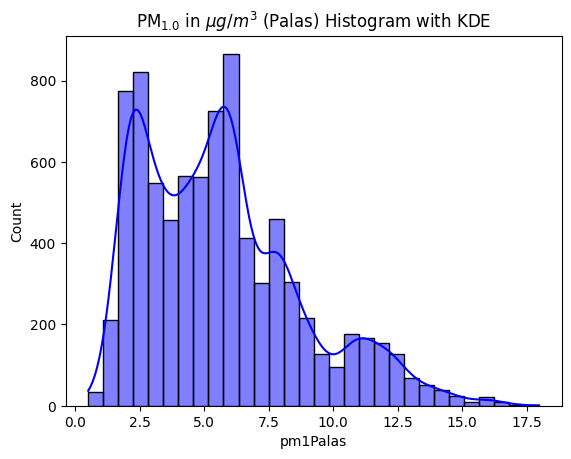

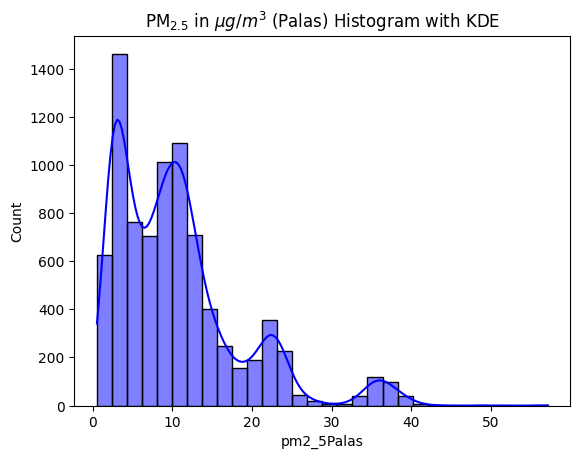

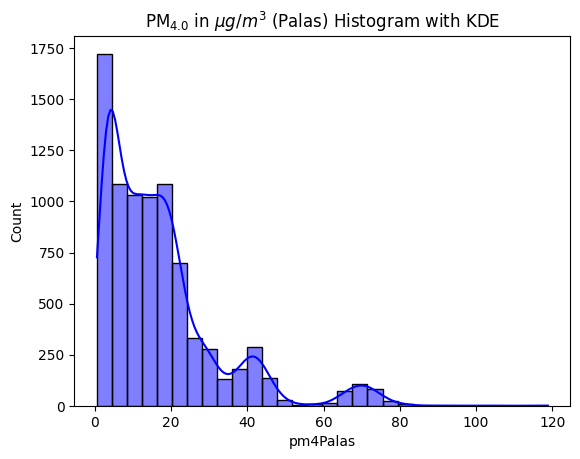

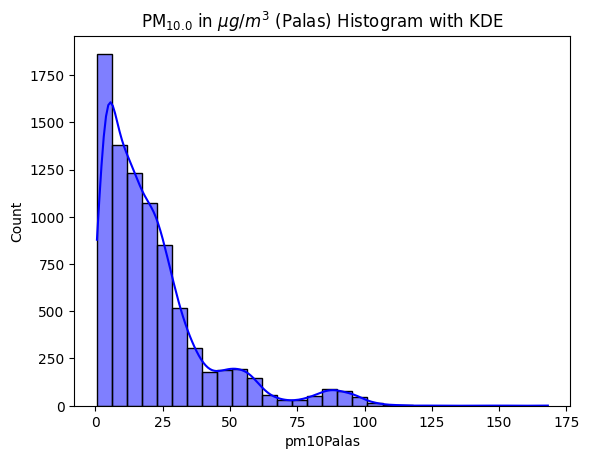

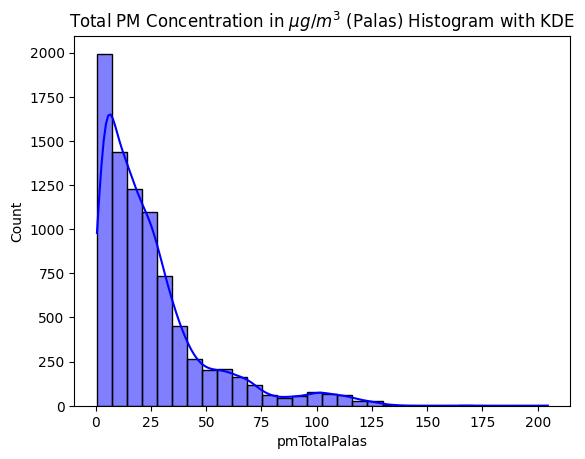

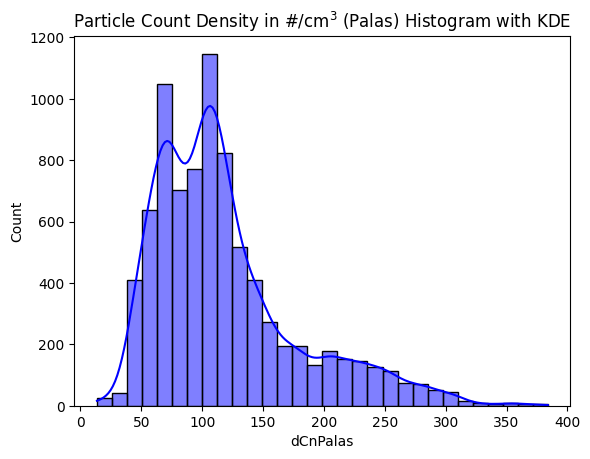

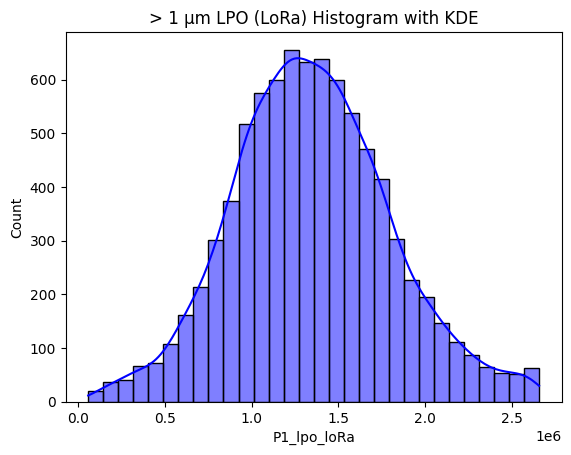

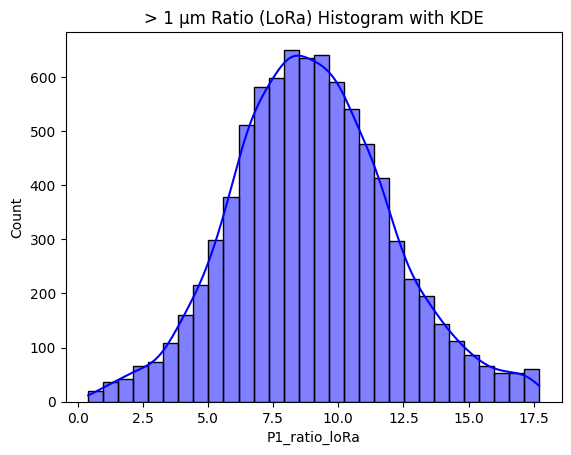

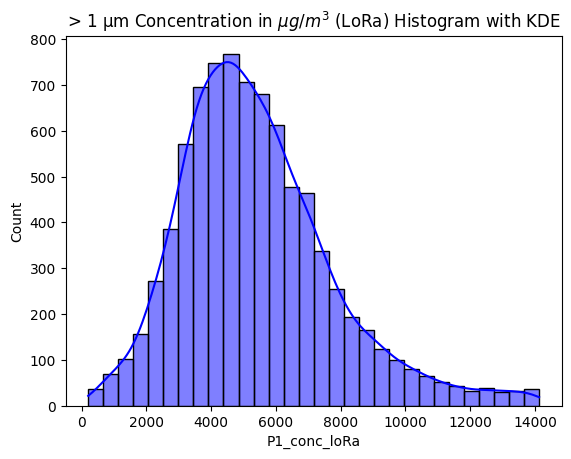

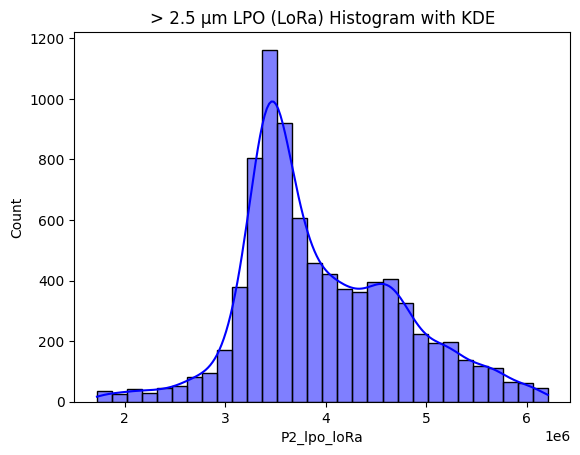

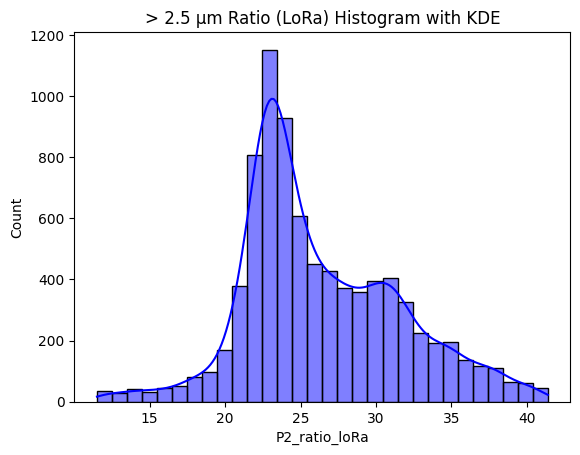

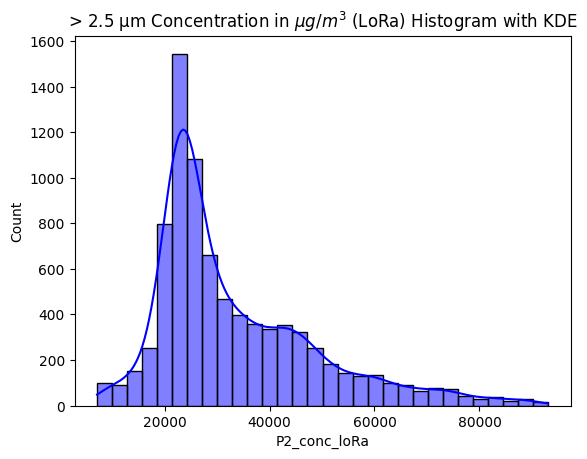

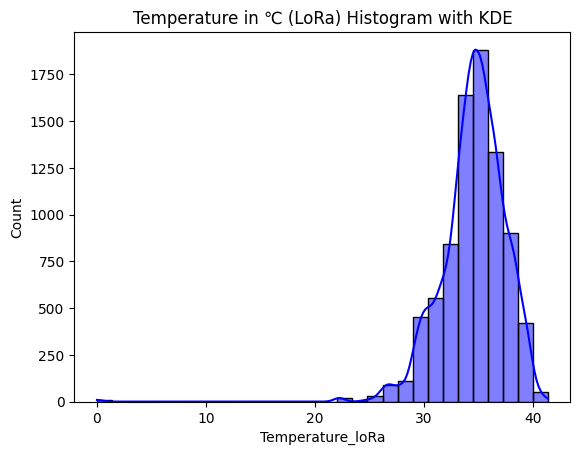

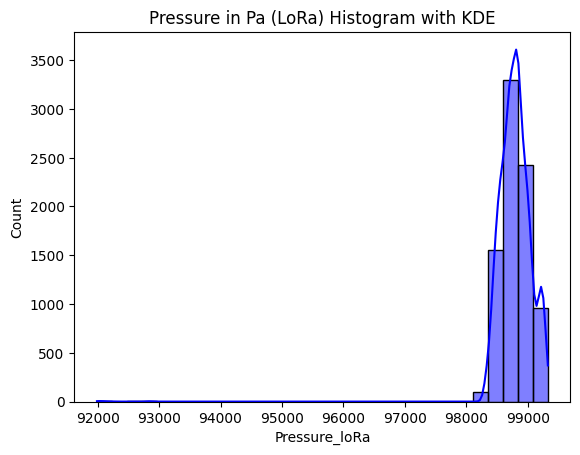

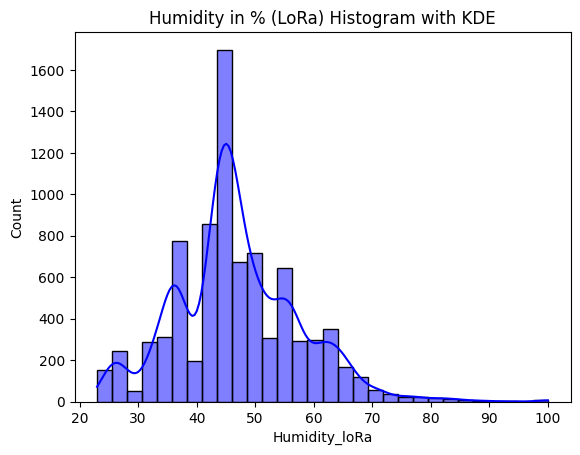

In [262]:
def hist_plots(df):
    for col in df.columns[1:len(df.columns)]:
        sns.histplot(df[col], kde = True, color = 'blue', bins = 30)
        plt.title(f'{dict_col_names[col]} Histogram with KDE')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()
hist_plots(df)

In [263]:
############# Plotting box plot for each parameter ################

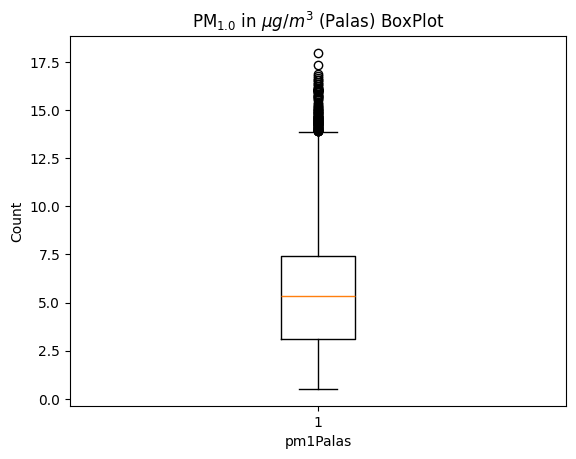

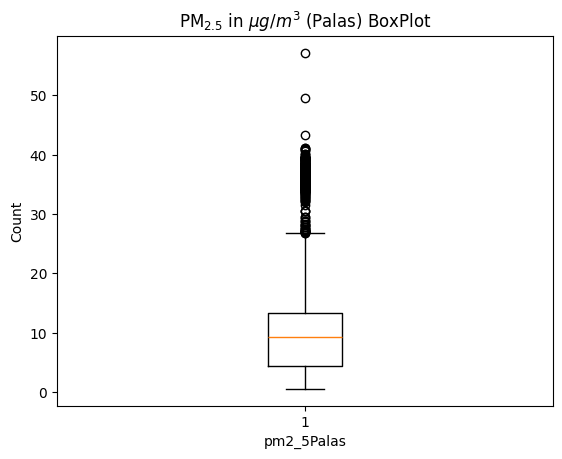

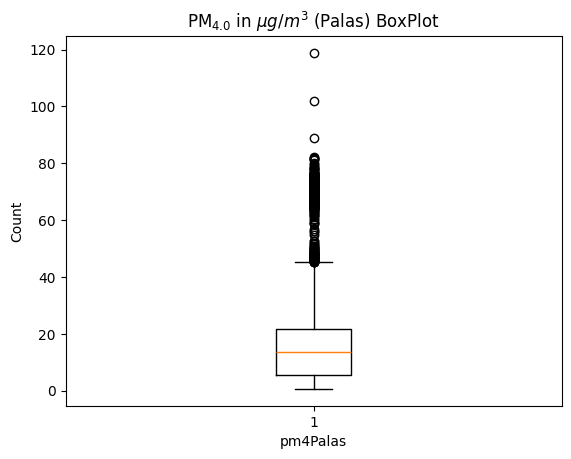

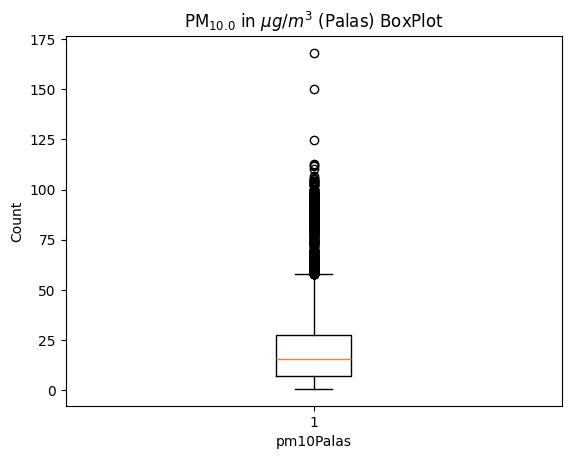

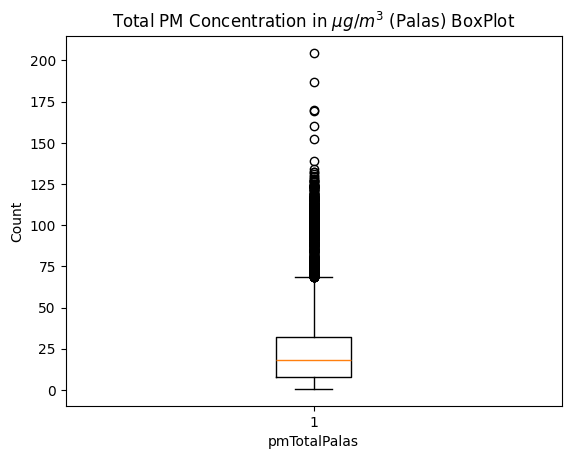

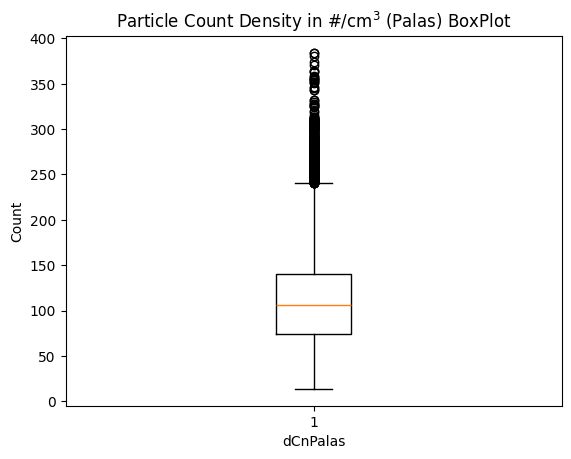

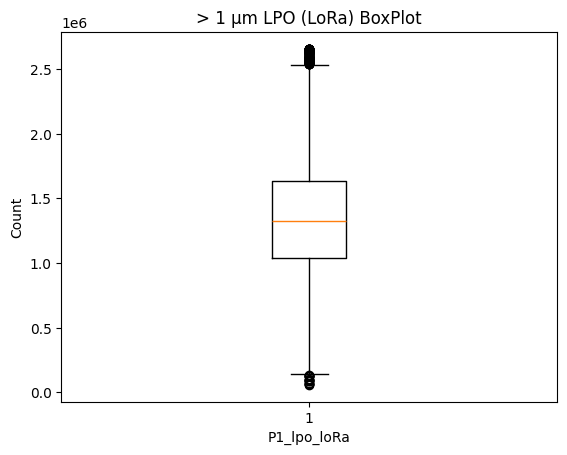

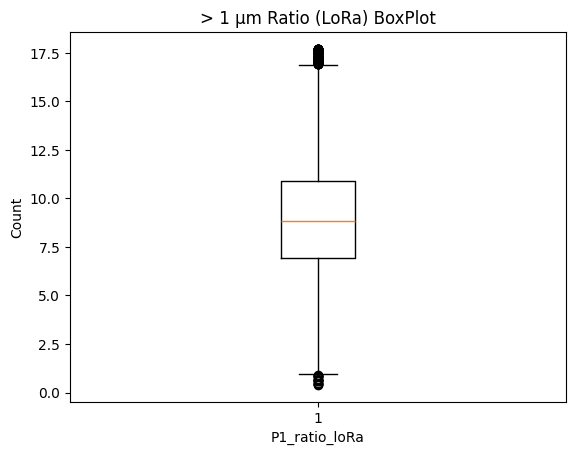

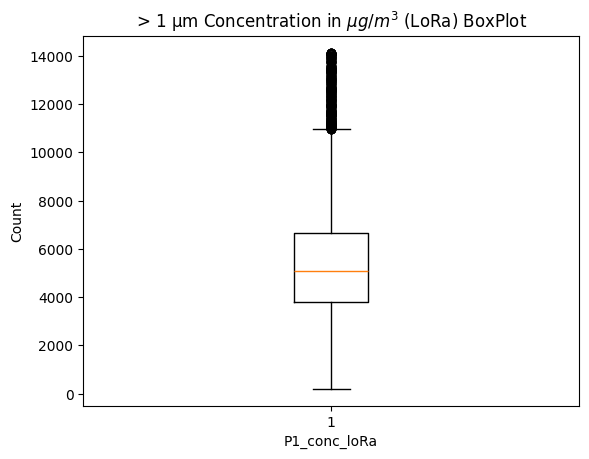

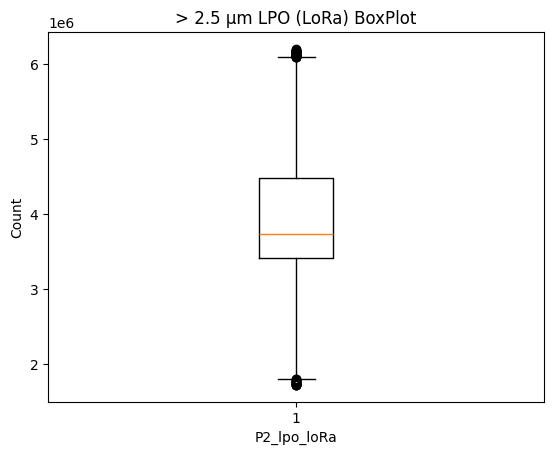

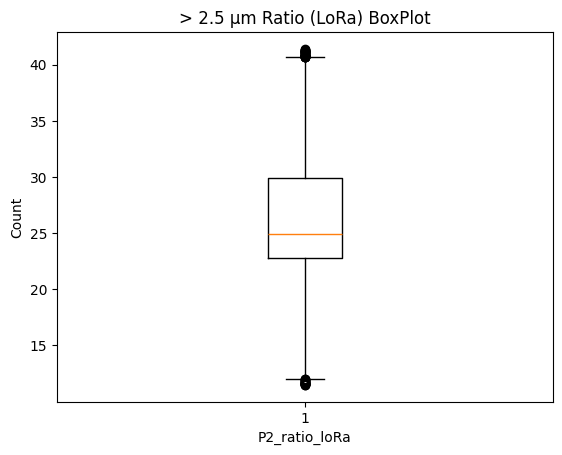

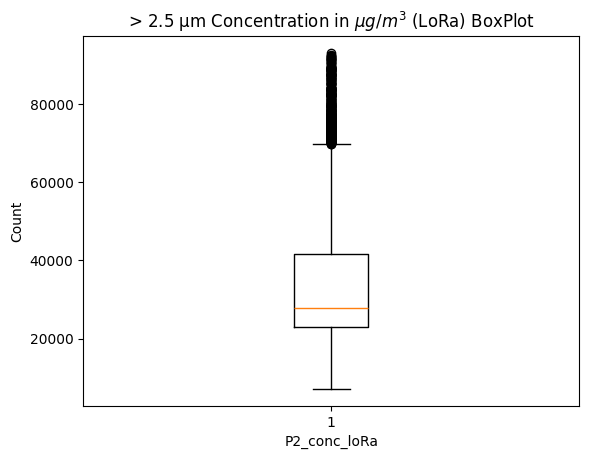

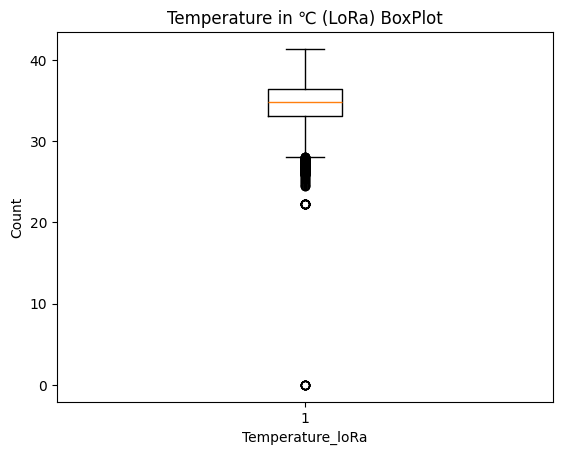

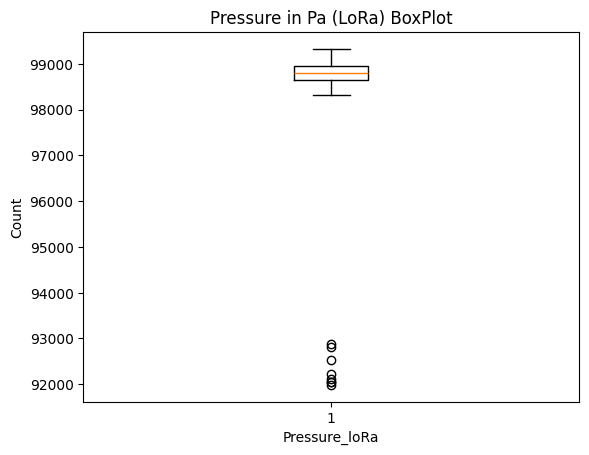

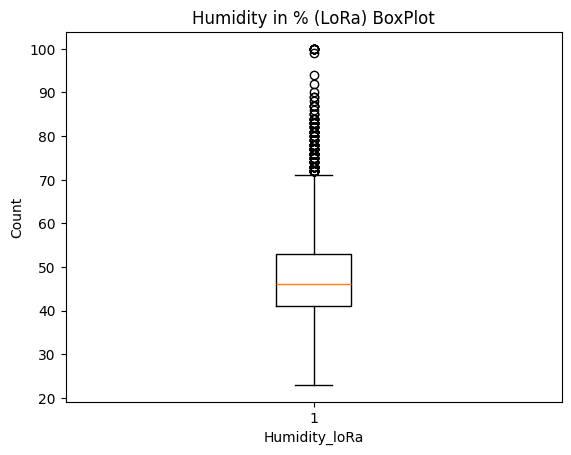

In [264]:
def box_plots(df):
    for col in df.columns[1:len(df.columns)]:
        plt.boxplot(df[col])
        plt.title(f'{dict_col_names[col]} BoxPlot')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()
box_plots(df)

In [265]:
df_up = df.iloc[:,1:len(df.columns)]
df_up

,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
0,2.718542,2.820000,3.085417,3.112500,3.148958,97.440417,2051025.0,13.67,9212.48,3820665.0,25.47,28957.81,32.78,99243.0,37.0
1,2.067500,2.130000,2.232708,2.231875,2.232708,73.388750,2175028.0,14.50,10095.36,4235407.0,28.24,36416.78,32.90,99247.0,36.0
2,1.904375,2.000000,2.135833,2.132083,2.135833,66.655000,1672212.0,11.15,6849.39,3967298.0,26.45,31447.53,32.89,99246.0,36.0
3,1.681458,1.876042,2.078333,2.072917,2.086667,58.758958,2295499.0,15.30,11010.73,3623442.0,24.16,25849.88,33.07,99248.0,37.0
4,1.540208,1.661458,1.834792,1.824792,1.834792,57.921875,1544578.0,10.30,6153.25,3452410.0,23.02,23367.73,33.12,99246.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8326,4.982917,12.055000,21.223333,31.216250,37.864167,77.197500,995050.0,6.63,3604.02,3534290.0,23.56,24532.03,36.60,98497.0,39.0
8327,4.544583,9.235833,15.932083,17.556667,19.295000,71.974583,1126826.0,7.51,4158.83,3641409.0,24.28,26121.92,36.71,98501.0,39.0
8328,4.834167,10.393750,16.646667,24.890000,29.965000,72.302500,938517.0,6.26,3374.82,3211260.0,21.41,20184.45,36.71,98497.0,39.0
8329,4.537917,9.765417,16.986667,18.576667,20.265833,70.609167,861083.0,5.74,3068.57,4171597.0,27.81,35183.72,36.61,98495.0,39.0


In [266]:
###################### Removing Outliers using IQR method ############################

In [267]:

iqr_multiplier = 1.5

def filter_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - iqr_multiplier * iqr
    upper_bound = q3 + iqr_multiplier * iqr
    return (series >= lower_bound) & (series <= upper_bound)

# Apply the filter_outliers function to each column
filtered_df = df_up.apply(filter_outliers)

filtered_df #If you chcek row 3 there is a mix of true and false values
# In the next part of the code that row will be removed since there is one outlier
# A row with atleast one outlier will be removed. 

,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8326,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8327,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8328,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8329,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [268]:
# Combine the filters for all parameters using logical AND
final_filter = filtered_df.all(axis=1)

# Apply the final filter to the original DataFrame
filtered_data = df[final_filter]

# Display the filtered DataFrame
filtered_data


,dateTime,pm1Palas,pm2_5Palas,pm4Palas,pm10Palas,pmTotalPalas,dCnPalas,P1_lpo_loRa,P1_ratio_loRa,P1_conc_loRa,P2_lpo_loRa,P2_ratio_loRa,P2_conc_loRa,Temperature_loRa,Pressure_loRa,Humidity_loRa
0,2020-06-17T16:32:00.0,2.718542,2.820000,3.085417,3.112500,3.148958,97.440417,2051025.0,13.67,9212.48,3820665.0,25.47,28957.81,32.78,99243.0,37.0
1,2020-06-17T16:33:00.0,2.067500,2.130000,2.232708,2.231875,2.232708,73.388750,2175028.0,14.50,10095.36,4235407.0,28.24,36416.78,32.90,99247.0,36.0
2,2020-06-17T16:33:30.0,1.904375,2.000000,2.135833,2.132083,2.135833,66.655000,1672212.0,11.15,6849.39,3967298.0,26.45,31447.53,32.89,99246.0,36.0
4,2020-06-17T16:37:00.0,1.540208,1.661458,1.834792,1.824792,1.834792,57.921875,1544578.0,10.30,6153.25,3452410.0,23.02,23367.73,33.12,99246.0,37.0
5,2020-06-17T16:37:30.0,1.505000,1.545208,1.643333,1.640833,1.643333,58.833958,1418400.0,9.46,5508.03,3546983.0,23.65,24716.44,32.95,99244.0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8326,2020-07-15T00:27:30.0,4.982917,12.055000,21.223333,31.216250,37.864167,77.197500,995050.0,6.63,3604.02,3534290.0,23.56,24532.03,36.60,98497.0,39.0
8327,2020-07-15T00:29:00.0,4.544583,9.235833,15.932083,17.556667,19.295000,71.974583,1126826.0,7.51,4158.83,3641409.0,24.28,26121.92,36.71,98501.0,39.0
8328,2020-07-15T00:30:00.0,4.834167,10.393750,16.646667,24.890000,29.965000,72.302500,938517.0,6.26,3374.82,3211260.0,21.41,20184.45,36.71,98497.0,39.0
8329,2020-07-15T00:30:30.0,4.537917,9.765417,16.986667,18.576667,20.265833,70.609167,861083.0,5.74,3068.57,4171597.0,27.81,35183.72,36.61,98495.0,39.0


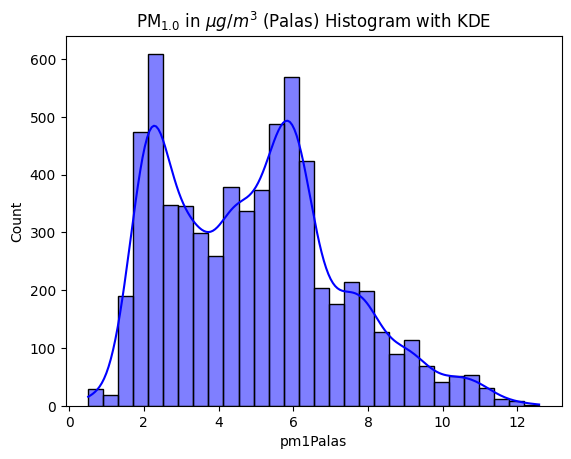

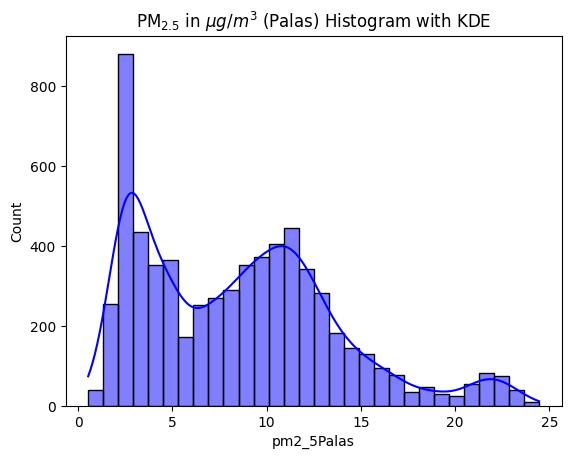

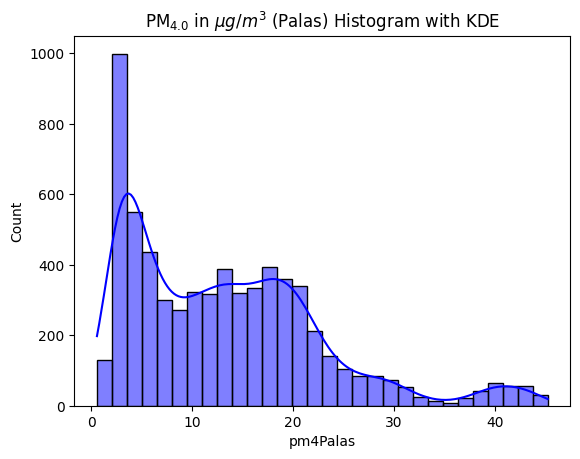

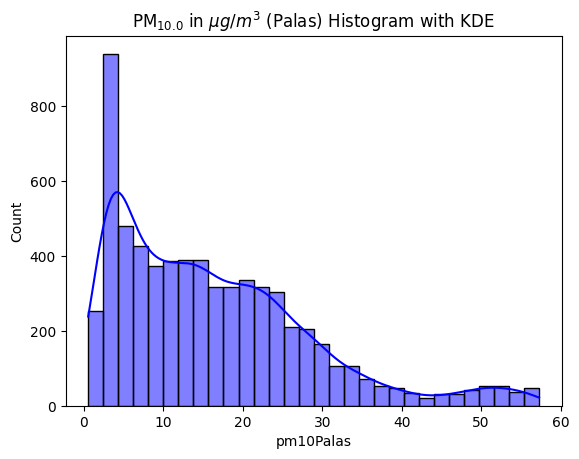

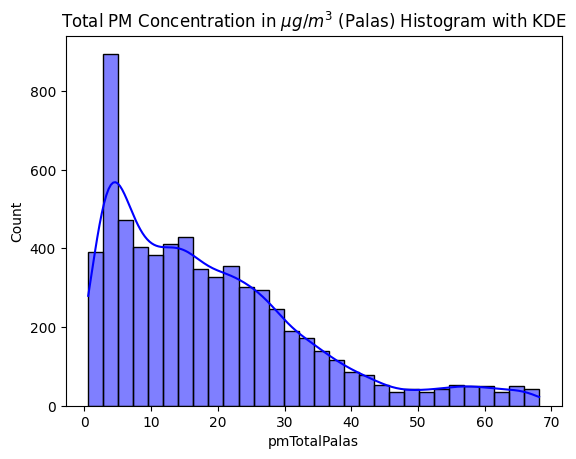

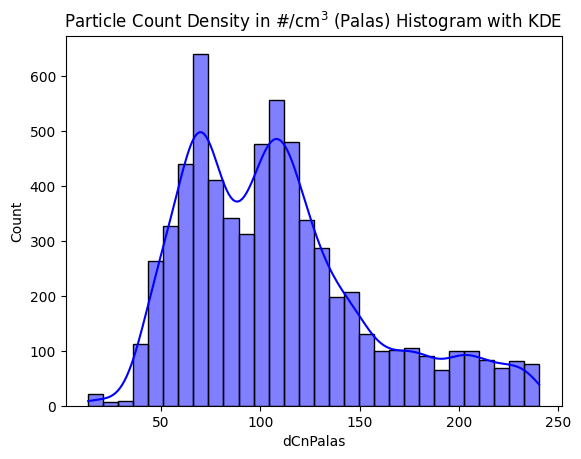

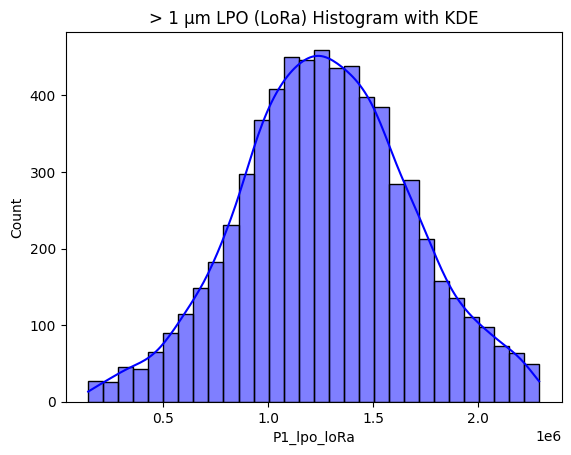

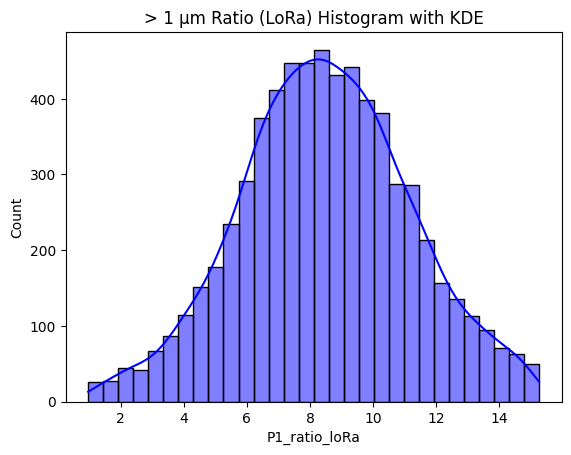

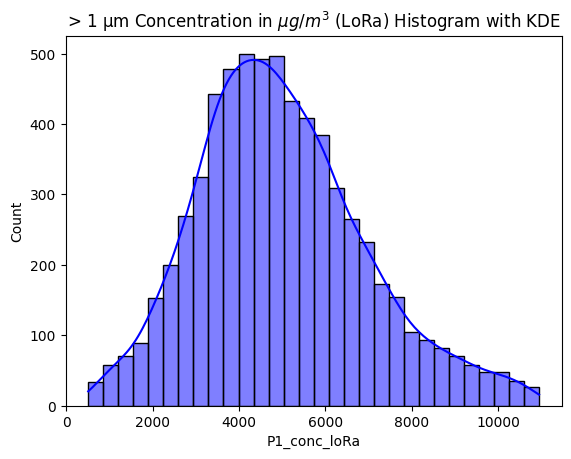

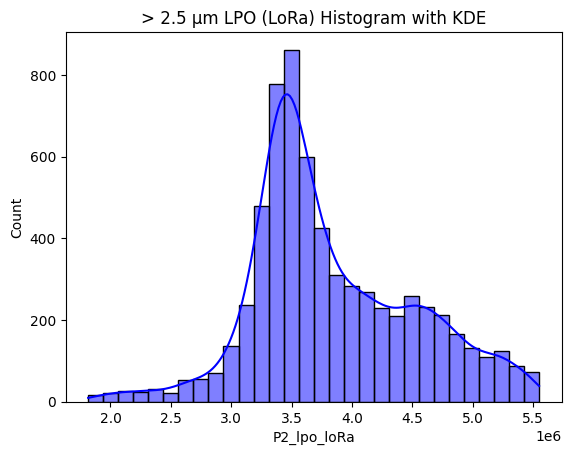

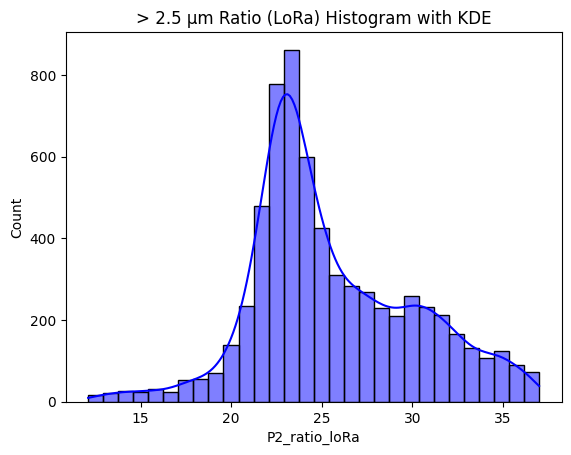

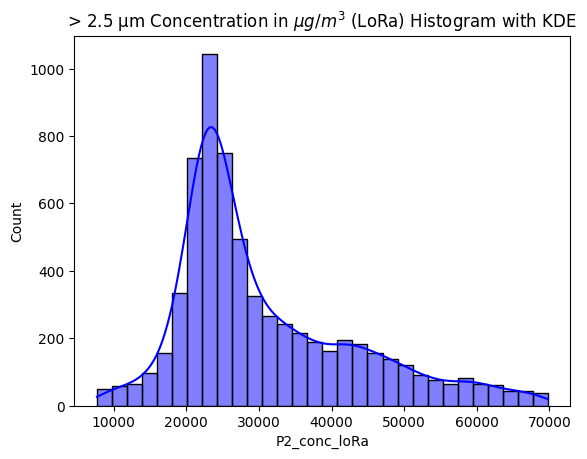

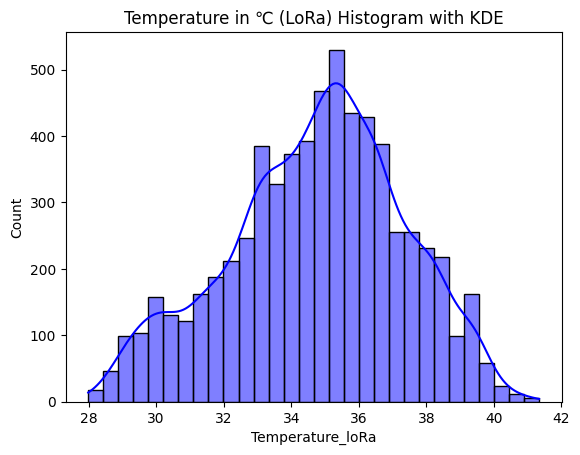

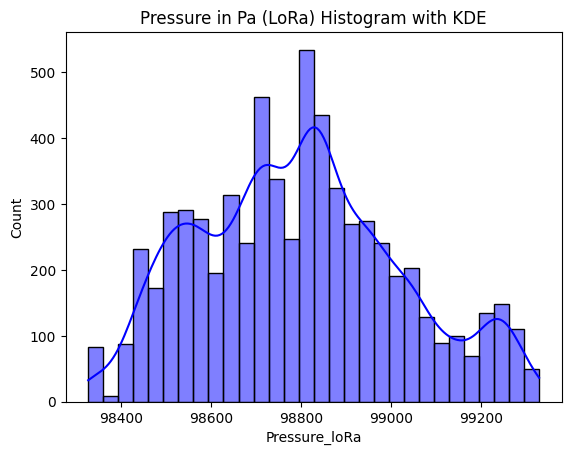

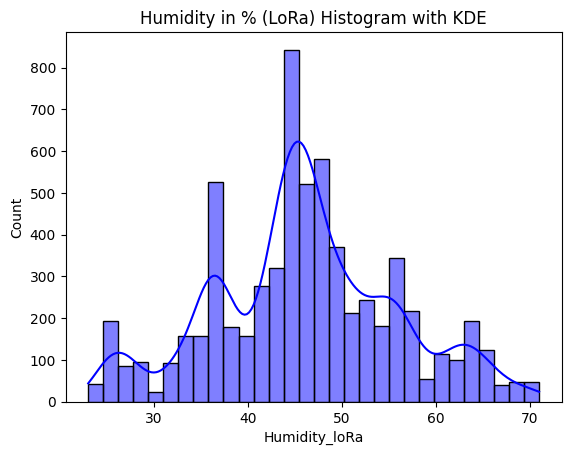

In [269]:
hist_plots(filtered_data)

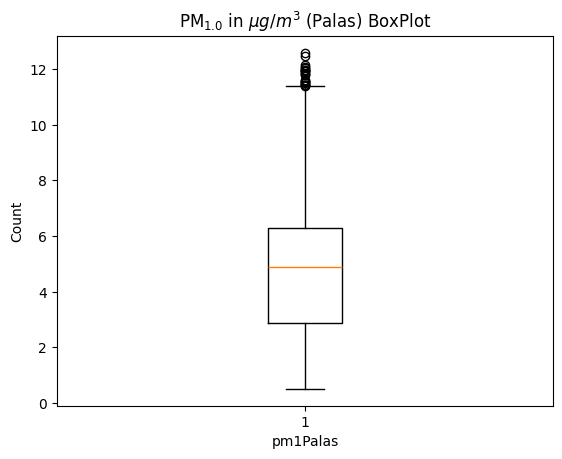

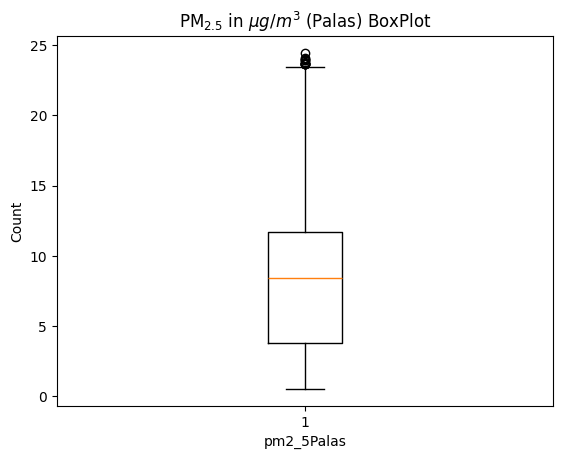

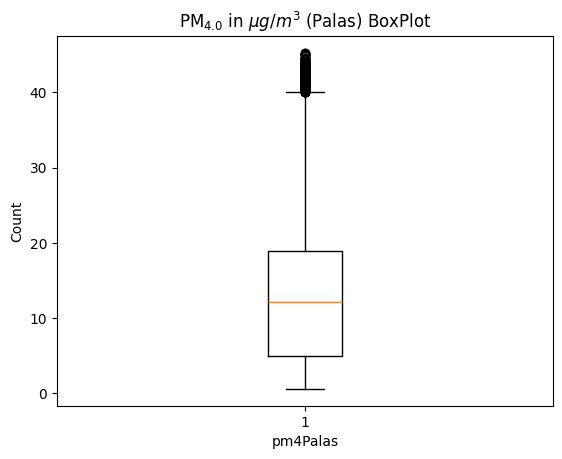

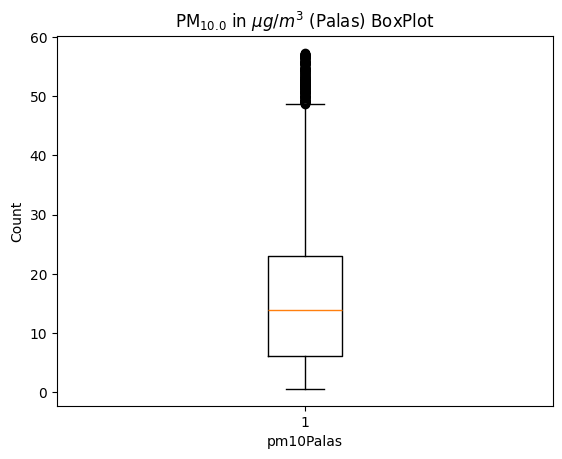

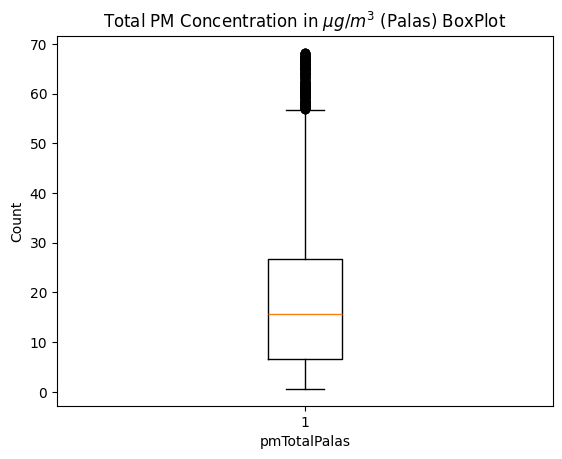

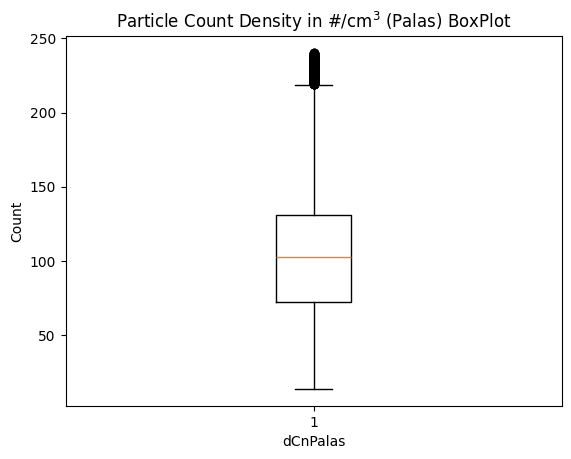

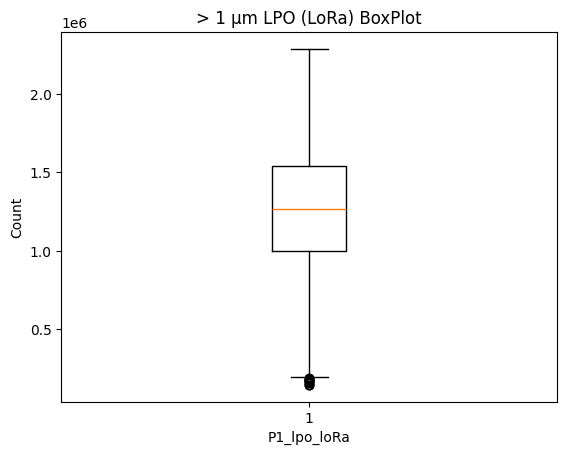

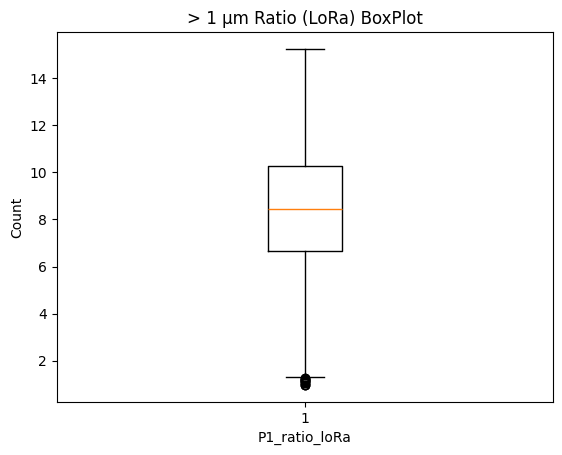

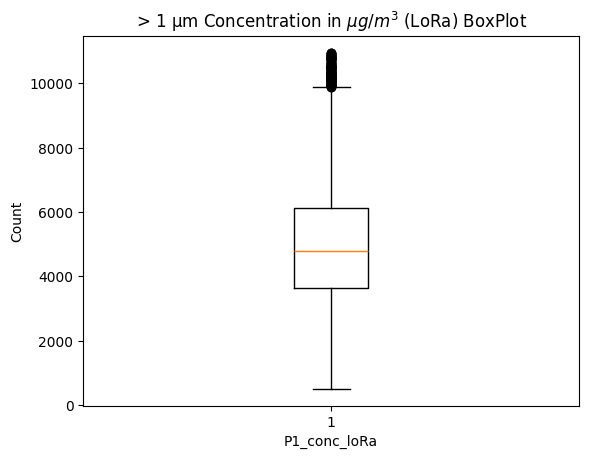

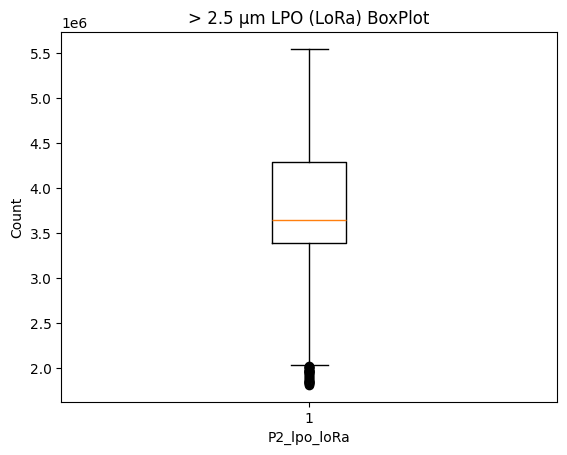

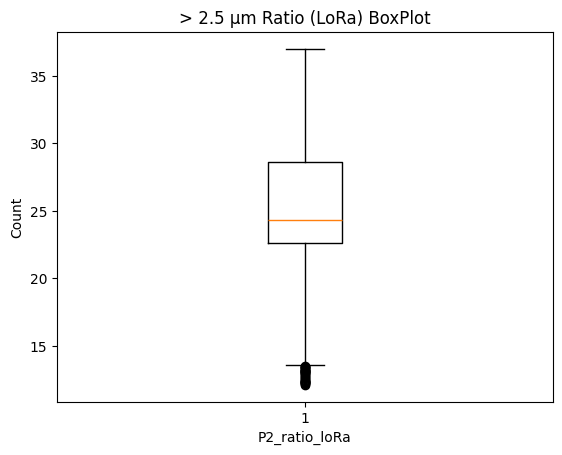

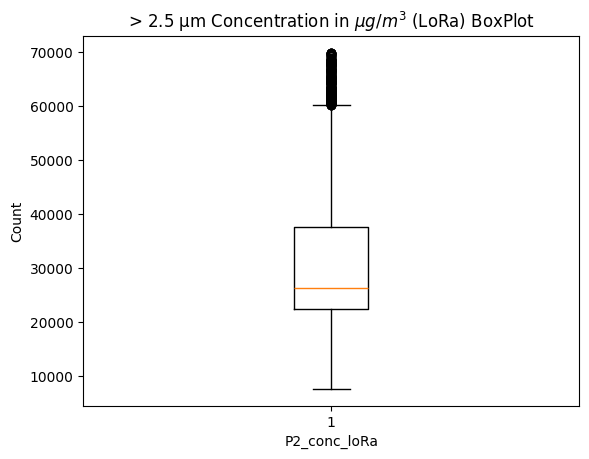

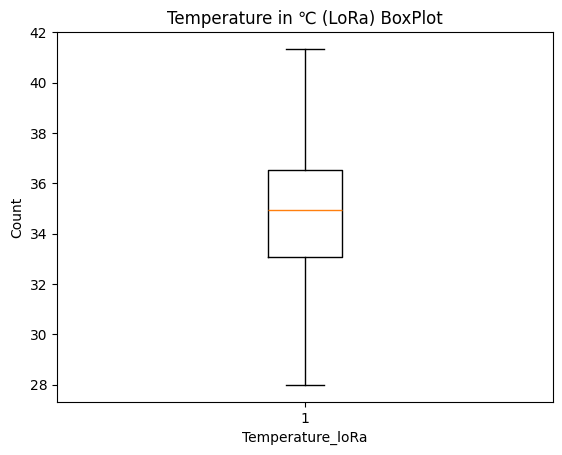

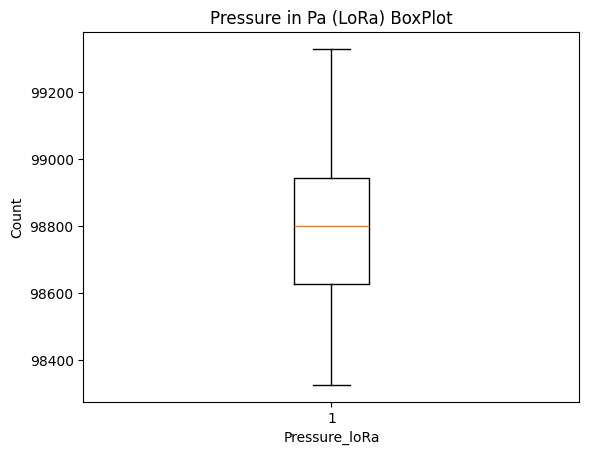

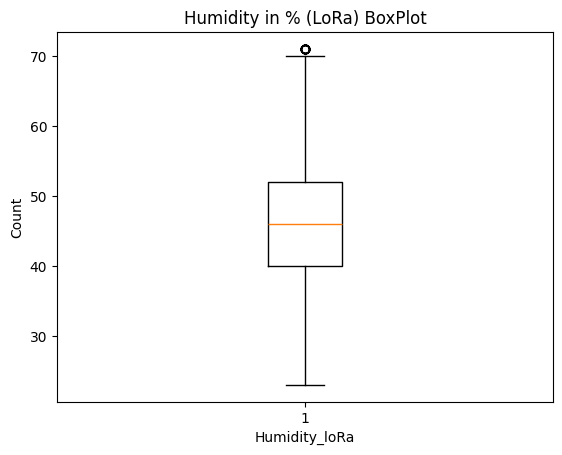

In [270]:
box_plots(filtered_data)

In [271]:
######################### Start Running various Machine Learning Models ###########################

In [272]:
#Linear Regression

In [273]:
col_name = list(filtered_data)
x =[]
y_Palas  = []
for i in col_name:
    if "_loRa" in i:
        x.append(i)
    if "Palas" in i:
        y_Palas.append(i)
Palas = {}
for i in y_Palas:
    Palas_cols = x + [i]
    Palas[i[:-len("Palas")]] = filtered_data[Palas_cols]
y_Palas

['pm1Palas', 'pm2_5Palas', 'pm4Palas', 'pm10Palas', 'pmTotalPalas', 'dCnPalas']

In [274]:
def plot_residuals(predict_test,y_test,filtered_data):
    idx = X_test.index
    data_test = filtered_data.loc[idx]
    data_test["dateTime"] = pd.to_datetime(data_test["dateTime"])
    residuals = (np.array(y_test) - predict_test)**2
    plt.figure()
    plt.scatter(data_test["dateTime"], residuals)
    plt.xticks(rotation = 45)
    plt.xlabel('Date Time')
    plt.ylabel(y_test.name)
    plt.show()

In [275]:
dict_col_regression = {'pm1Palas':'PM$_{1.0}$', 
                       'pm2_5Palas': 'PM$_{2.5}$',
                       'pm4Palas': 'PM$_{4.0}$',
                       'pm10Palas': 'PM$_{10.0}$',
                       'pmTotalPalas': 'Total PM Concentration', 
                       'dCnPalas': 'Particle Count Density',
                       'dateTime': 'Date Time',
                       'P1_lpo_loRa':'> 1 μm LPO',
                       'P1_ratio_loRa': '> 1 μm ratio', 
                       'P1_conc_loRa': '> 1 μm Concentration', 
                       'P2_lpo_loRa': '> 2.5 μm LPO', 
                       'P2_ratio_loRa': '> 2.5 μm ratio',
                       'P2_conc_loRa': '> 2.5 μm Concentration' , 
                       'Temperature_loRa': 'Temperature', 
                       'Pressure_loRa': 'Pressure', 
                       'Humidity_loRa':'Humidity'}
unit_regression = {'pm_conc':'($\mu g/m^3$)',
                   'dCn':'(#/cm$^{3}$)'} 

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
C:\Users\balag\AppData\Local\Temp\ipykernel_18792\1463428285.py:17: SyntaxWarning: invalid escape sequence '\m'
  unit_regression = {'pm_conc':'($\mu g/m^3$)',


x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000416 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

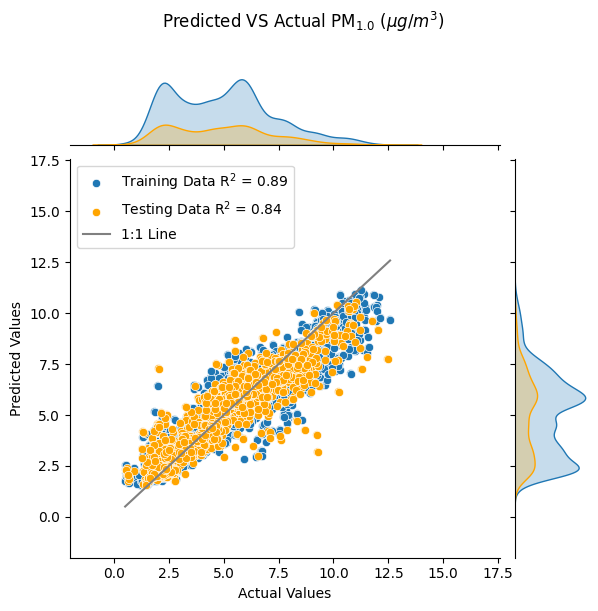

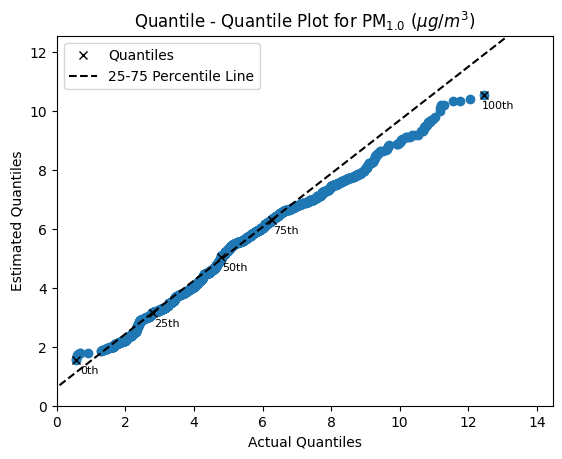

x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

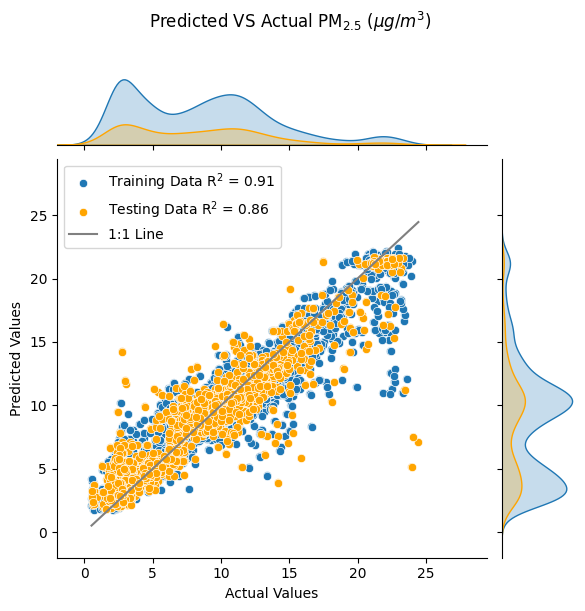

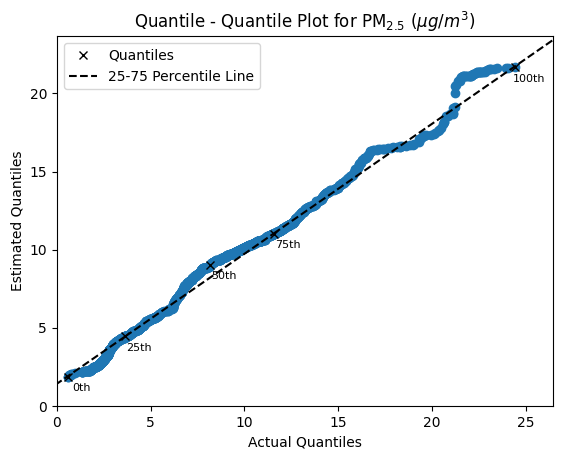

x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000640 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

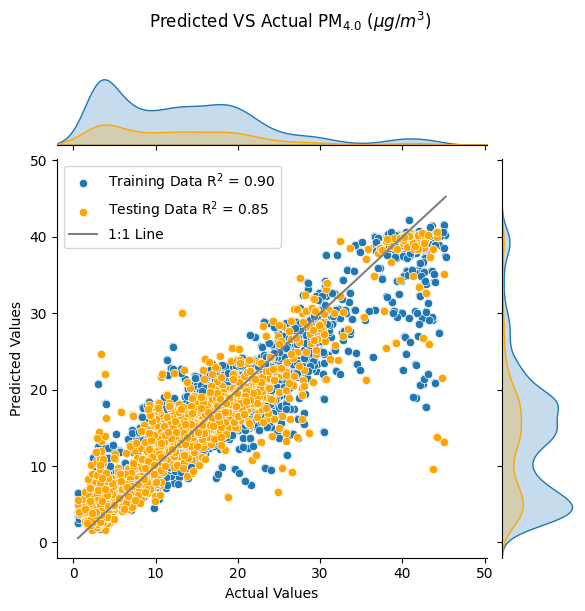

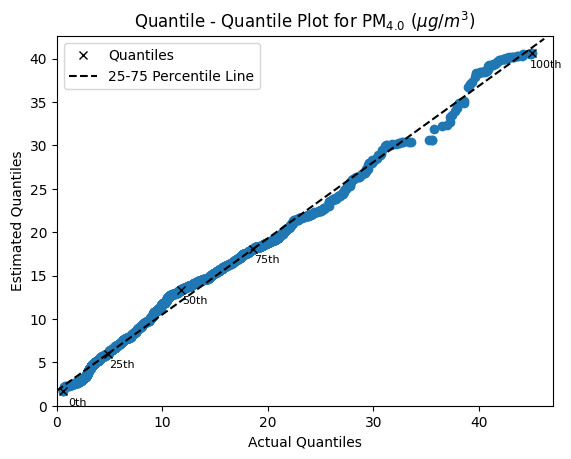

x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

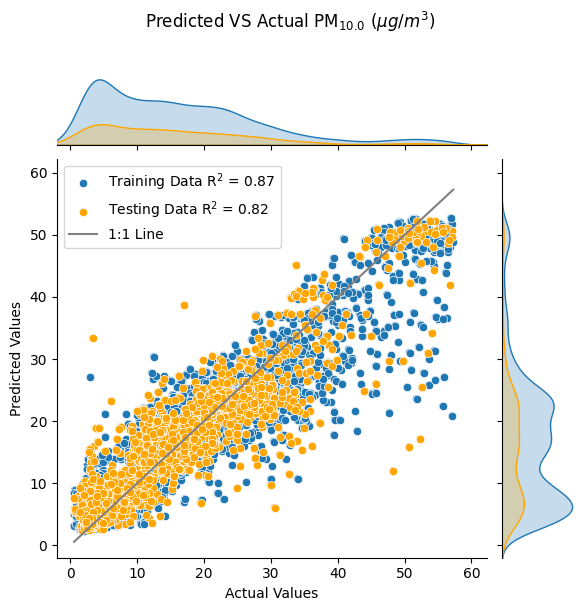

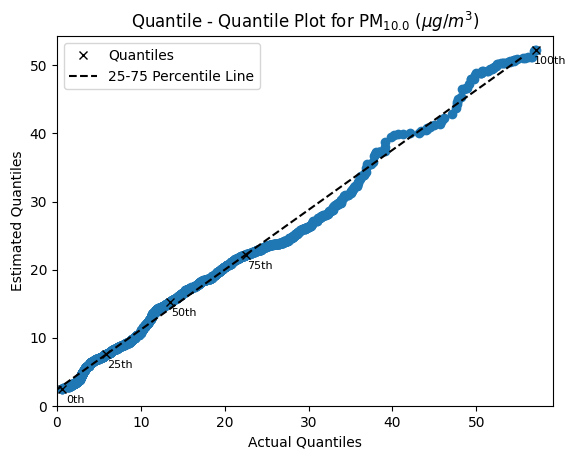

x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

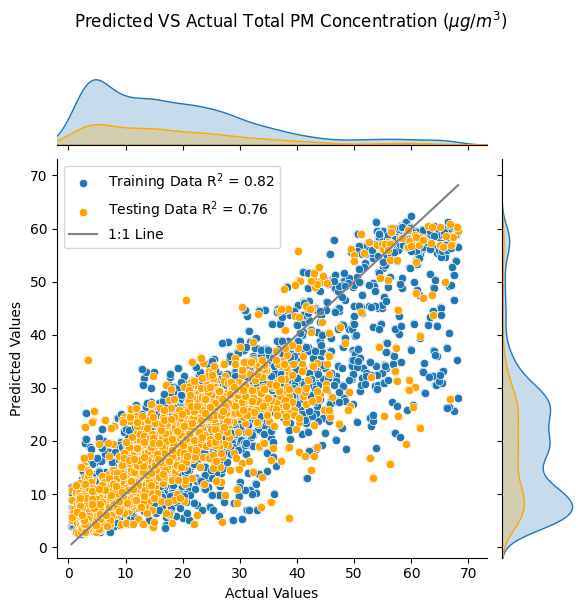

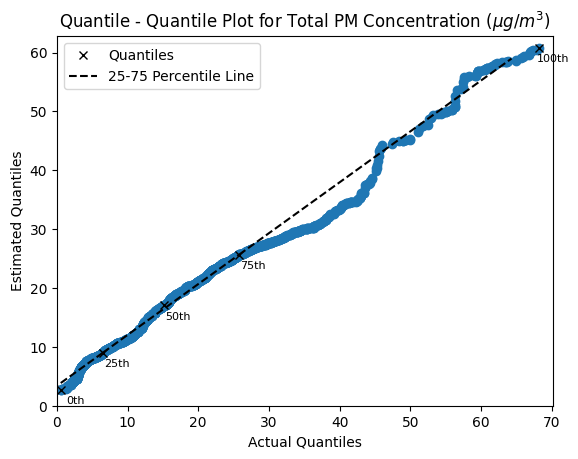

x train (4896, 9)
x test (1632, 9)
y train (4896,)
y test (1632,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2090
[LightGBM] [Info] Number of data points in the train set: 3916, number of used features: 9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of

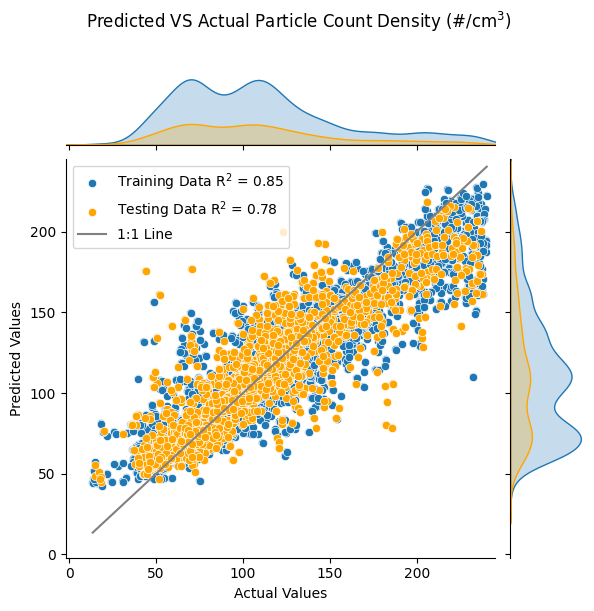

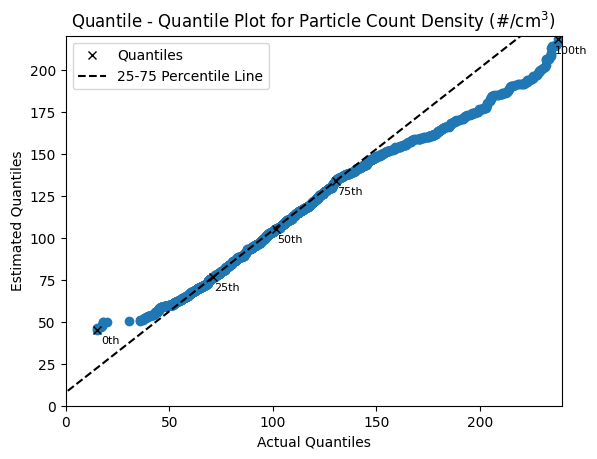

In [287]:
%run D:/UTD/UTDFall2023/Calibration-of-LoRaNodes-using-Super-Learners/models/Linear_Regression.ipynb
%run D:/UTD/UTDFall2023/Calibration-of-LoRaNodes-using-Super-Learners/models/Random_Forest_Regression.ipynb
%run D:/UTD/UTDFall2023/Calibration-of-LoRaNodes-using-Super-Learners/models/Decision_Tree_Regression.ipynb
%run D:/UTD/UTDFall2023/Calibration-of-LoRaNodes-using-Super-Learners/models/LGBM_Regression.ipynb

for k,v in enumerate(Palas):
    #v='pm1'
    X = Palas[v].drop([v+"Palas"],axis = 1)
    y = Palas[v][v+"Palas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state= 40)
    print("x train",X_train.shape)
    print("x test",X_test.shape)
    print("y train",y_train.shape)
    print("y test",y_test.shape)
    # Linear_Regression(X_train,X_test,y_train,y_test,filtered_data)
    # Random_Forest_Regression(X_train,X_test,y_train,y_test,filtered_data)   
    # Decision_Tree_Regression(X_train,X_test,y_train,y_test,filtered_data)   
    LGBM_Regression(X_train,X_test,y_train,y_test,filtered_data)

In [ ]:
##################### Ridge Regressor ######################
####################  Ensemble Bagging ####################
#################### LGBM #########################
#################### Decision Trees ##################
#################### Random Forest Regression ##################
